In [1]:
import os, sys, glob, subprocess
import torch
print("python", sys.version.split()[0], "| torch", torch.__version__, "| cuda:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown

DATA = "/kaggle/working/data"; os.makedirs(DATA, exist_ok=True)
FOLDER = "https://drive.google.com/drive/folders/1R4pOtvDEYyXtjLgVsT2RsmaORKOzoEq2"
try:
    gdown.download_folder(FOLDER, output=DATA, quiet=True, use_cookies=False, remaining_ok=True)
except Exception as e:
    print("download failed:", repr(e)[:300])
files = sorted(p for p in glob.glob(f"{DATA}/**/*", recursive=True) if os.path.isfile(p))
if not files:                                   
    files = sorted(p for p in glob.glob("/kaggle/input/**/*", recursive=True) if os.path.isfile(p))
print("files found:", len(files))
for p in files:
    size = os.path.getsize(p)
    print(f"\n{p} | {size/1e6:.2f} MB")
    if p.lower().endswith((".zip", ".gz", ".tar", ".tgz", ".pt", ".pkl", ".bin")):
        print("  compressed or binary file, not shown"); continue
    if size < 200e6:
        n, head = 0, []
        with open(p, encoding="utf-8", errors="replace") as f:
            for line in f:
                n += 1
                if n <= 5: head.append(line.rstrip("\n")[:200])
        print("  lines:", n)
        for l in head: print("  ", repr(l))

python 3.13.15 | torch 2.11.0+cu128 | cuda: True Tesla T4
files found: 3

/kaggle/working/data/en_fr_test.csv | 1.74 MB
  lines: 8598
   'en,fr'
   '"Several years ago here at TED, Peter Skillman  introduced a design challenge  called the marshmallow challenge.","Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de concepti'
   '"And the idea\'s pretty simple:  Teams of four have to build the tallest free-standing structure  out of 20 sticks of spaghetti,  one yard of tape, one yard of string  and a marshmallow.","Et l\'idée es'
   'The marshmallow has to be on top.,Le marshmallow doit être placé au sommet.'
   '"And, though it seems really simple, it\'s actually pretty hard  because it forces people  to collaborate very quickly.","Bien que cela semble vraiment simple, c\'est en fait plutôt difficile, parce que'

/kaggle/working/data/en_fr_train.csv | 48.47 MB
  lines: 232826
   'en,fr'
   '"Thank you so much, Chris. And it\'s truly a great honor to have the opp

In [2]:
import re, random, collections, subprocess, sys
import numpy as np
try:
    import sacrebleu
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"], check=True)
    import sacrebleu

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

PUNCT = r".,!?;:\"“”()\[\]।"
TOK = re.compile(rf"[^\s{PUNCT}]+|[{PUNCT}]")
def tokenize(text): return TOK.findall(text.lower().strip())

class Vocab:
    PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
    def __init__(self, sentences, max_size=10000, min_freq=2):
        counts = collections.Counter(t for s in sentences for t in s)
        self.itos = [self.PAD, self.SOS, self.EOS, self.UNK]
        for tok, c in counts.most_common():
            if c < min_freq or len(self.itos) >= max_size: break
            self.itos.append(tok)
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.pad, self.sos, self.eos, self.unk = 0, 1, 2, 3
    def __len__(self): return len(self.itos)
    def encode(self, toks, add_se=False):
        ids = [self.stoi.get(t, self.unk) for t in toks]
        return [self.sos] + ids + [self.eos] if add_se else ids
    def decode(self, ids, stop_at_eos=True):
        out = []
        for i in ids:
            if i == self.eos and stop_at_eos: break
            if i in (self.pad, self.sos): continue
            out.append(self.itos[i])
        return out

for s in ["I am hungry.", "Je n'ai pas faim, mais j'ai soif !", "मैं भूखा हूँ।"]:
    print(tokenize(s))
corpus = [tokenize(s) for s in ["the cat sat on the mat", "the dog sat on the log", "a bird flew"]]
v = Vocab(corpus, max_size=100, min_freq=2); print("vocab:", v.itos)
ids = v.encode(tokenize("the cat flew"), add_se=True); print("encode:", ids, "| decode:", v.decode(ids))
print("sacrebleu", sacrebleu.__version__, "| BLEU check:", round(sacrebleu.sentence_bleu("the cat sat on a mat", ["the cat sat on the mat"], smooth_method="none").score, 1), "(expect 53.7)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 5.1 MB/s eta 0:00:00
['i', 'am', 'hungry', '.']
['je', "n'ai", 'pas', 'faim', ',', 'mais', "j'ai", 'soif', '!']
['मैं', 'भूखा', 'हूँ', '।']
vocab: ['<pad>', '<sos>', '<eos>', '<unk>', 'the', 'sat', 'on']
encode: [1, 4, 3, 3, 2] | decode: ['the', '<unk>', '<unk>']
sacrebleu 2.6.0 | BLEU check: 53.7 (expect 53.7)


In [3]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
    def forward(self, src, src_len):                     
        x = self.drop(self.emb(src))
        packed = nn.utils.rnn.pack_padded_sequence(x, src_len.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, c) = self.rnn(packed)                     
        return h, c                                      

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.out = nn.Linear(hidden, vocab_size)
        self.drop = nn.Dropout(dropout)
    def forward(self, tok, h, c):                        
        x = self.drop(self.emb(tok)).unsqueeze(1)        
        o, (h, c) = self.rnn(x, (h, c))
        return self.out(o.squeeze(1)), h, c              

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__(); self.enc, self.dec = enc, dec
    def forward(self, src, src_len, tgt, tf_ratio=1.0):
        h, c = self.enc(src, src_len)
        tok, outs = tgt[:, 0], []
        for t in range(1, tgt.shape[1]):
            out, h, c = self.dec(tok, h, c)
            outs.append(out)
            tok = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return torch.stack(outs, dim=1)                  

V, PAD = 1000, 0
torch.manual_seed(SEED)
model = Seq2Seq(Encoder(V, 64, 128, 1, 0.0, PAD), Decoder(V, 64, 128, 1, 0.0, PAD)).to(device)
print("parameters:", sum(p.numel() for p in model.parameters()), "| expected 455656")
src = torch.randint(4, V, (8, 7), device=device); src_len = torch.tensor([7, 5, 3, 6, 7, 4, 7, 2])
for i, L in enumerate(src_len.tolist()): src[i, L:] = PAD
tgt = torch.randint(4, V, (8, 9), device=device); tgt[:, 0] = 1
logits = model(src, src_len, tgt, tf_ratio=1.0)
print("logits shape:", tuple(logits.shape), "| expected (8, 8, 1000)")

lossf = nn.CrossEntropyLoss(ignore_index=PAD); opt = torch.optim.Adam(model.parameters(), lr=3e-3)
for step in range(300):                                  
    opt.zero_grad(); loss = lossf(model(src, src_len, tgt, 1.0).reshape(-1, V), tgt[:, 1:].reshape(-1))
    loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    if step in (0, 100, 200, 299): print("step", step, "loss", round(loss.item(), 4))
print("ln(V) =", round(float(np.log(V)), 3), "(loss of a random guesser)")

parameters: 455656 | expected 455656
logits shape: (8, 8, 1000) | expected (8, 8, 1000)
step 0 loss 6.919
step 100 loss 0.0142
step 200 loss 0.0049
step 299 loss 0.0026
ln(V) = 6.908 (loss of a random guesser)


In [10]:
import re, collections, pandas as pd
FILES = {"train": f"{DATA}/en_fr_train.csv", "val": f"{DATA}/en_fr_val.csv", "test": f"{DATA}/en_fr_test.csv"}
raw = {k: pd.read_csv(p) for k, p in FILES.items()}
for k, d in raw.items():
    print(k, d.shape, "| rows with a missing side:", int(d.isna().any(axis=1).sum()), "| exact duplicate pairs:", int(d.duplicated().sum()))

MARK_FR = re.compile(r"--\s*(?:Rires?|Applaudissements?|Faux sanglot|Musique|Vidéo)(?:\s+\w+)?\s*--", re.IGNORECASE)      
def clean_en(s): return re.sub(r"\s+", " ", str(s).replace("’", "'")).strip()
def clean_fr(s):
    s = MARK_FR.sub(" ", str(s)).replace("’", "'")
    return re.sub(r"\s+", " ", s).strip()
removed = collections.Counter(m.group(0) for s in raw["train"].fr.astype(str) for m in MARK_FR.finditer(s))
print("French stage directions removed (train):", sum(removed.values()), "| most common:", removed.most_common(8))
TAG = r"\((?:Laughter|Applause|Music|Video)[^)]*\)"
print("English rows with (Laughter)/(Applause)-style tags:", {k: int(d.en.astype(str).str.contains(TAG, case=False).sum()) for k, d in raw.items()})

data = {}
for k, d in raw.items():
    d = d.dropna().copy(); d["en"] = d.en.map(clean_en); d["fr"] = d.fr.map(clean_fr)
    data[k] = d[(d.en.str.len() > 0) & (d.fr.str.len() > 0)].reset_index(drop=True)
print("usable rows:", {k: len(d) for k, d in data.items()})
tr_pairs, tr_en = set(zip(data["train"].en, data["train"].fr)), set(data["train"].en)
for k in ("val", "test"):
    d = data[k]
    print(k, "| pairs also in train:", sum((e, f) in tr_pairs for e, f in zip(d.en, d.fr)), "| English sentences also in train:",
          int(d.en.isin(tr_en).sum()), "of", len(d))

PUNCT = r".,!?;:\"“”()\[\]।"
TOK = re.compile(rf"[^\s{PUNCT}]+|[{PUNCT}]")
def tok_en(t): return TOK.findall(t.lower())
def tok_fr_a(t): return TOK.findall(t.lower())                                   
def tok_fr_b(t): return TOK.findall(re.sub(r"(\w+')", r"\1 ", t.lower()))        

tr = data["train"]
len_en = np.array([len(tok_en(s)) for s in tr.en]); len_fr = np.array([len(tok_fr_b(s)) for s in tr.fr])
for name, L in (("English", len_en), ("French", len_fr)):
    print(name, "tokens per sentence: median %d | 90%% %d | 99%% %d | max %d" % (np.median(L), np.percentile(L, 90), np.percentile(L, 99), L.max()))
MAX_LEN = 50
ratio = (len_fr + 1) / (len_en + 1)
keep = (len_en >= 1) & (len_fr >= 1) & (len_en <= MAX_LEN) & (len_fr <= MAX_LEN) & (ratio <= 3) & (ratio >= 1 / 3)
print("train pairs kept: %d of %d (%.1f%%) | too long: %d | length ratio outside 1/3 to 3: %d" % (
    keep.sum(), len(tr), 100 * keep.mean(), int(((len_en > MAX_LEN) | (len_fr > MAX_LEN)).sum()), int(((ratio > 3) | (ratio < 1 / 3)).sum())))
tr_f = tr[keep].reset_index(drop=True)
worst = tr.assign(ratio=ratio).sort_values("ratio").iloc[[0, 1, -2, -1]]
for _, r in worst.iterrows(): print("  ratio %.2f | EN: %s | FR: %s" % (r.ratio, r.en[:90], r.fr[:90]))

def unk_rate(train_sents, eval_sents, max_size=10000, min_freq=2):
    counts = collections.Counter(t for s in train_sents for t in s)
    vocab = {t for t, c in counts.most_common(max_size - 4) if c >= min_freq}
    tot = sum(len(s) for s in eval_sents); unk = sum(t not in vocab for s in eval_sents for t in s)
    return len(vocab) + 4, unk / tot
va = data["val"]; rates = {}
for name, f in (("a", tok_fr_a), ("b", tok_fr_b)):
    size, u = unk_rate([f(s) for s in tr_f.fr], [f(s) for s in va.fr]); rates[name] = u
    print("French tokenization %s | vocab %5d | val <unk> rate %.4f" % (name, size, u))
size, u = unk_rate([tok_en(s) for s in tr_f.en], [tok_en(s) for s in va.en]); print("English | vocab %5d | val <unk> rate %.4f" % (size, u))
tok_fr = tok_fr_b if rates["b"] < rates["a"] else tok_fr_a
print("chosen French tokenization:", "b (split after apostrophes)" if tok_fr is tok_fr_b else "a (apostrophes kept)")

train (232825, 2) | rows with a missing side: 0 | exact duplicate pairs: 2054
val (890, 2) | rows with a missing side: 0 | exact duplicate pairs: 7
test (8597, 2) | rows with a missing side: 0 | exact duplicate pairs: 71
French stage directions removed (train): 14 | most common: [('--Rires--', 9), ('--Faux sanglot--', 2), ('--Applaudissements--', 2), ('--Rires Applaudissements--', 1)]
English rows with (Laughter)/(Applause)-style tags: {'train': 0, 'val': 0, 'test': 0}
usable rows: {'train': 232825, 'val': 890, 'test': 8597}
val | pairs also in train: 12 | English sentences also in train: 14 of 890
test | pairs also in train: 96 | English sentences also in train: 134 of 8597
English tokens per sentence: median 16 | 90% 38 | 99% 69 | max 136
French tokens per sentence: median 18 | 90% 41 | 99% 75 | max 135
train pairs kept: 220442 of 232825 (94.7%) | too long: 12320 | length ratio outside 1/3 to 3: 65
  ratio 0.13 | EN: Now, you talk straight to me, what's wrong with my films? | FR: -
 

In [11]:
import random, sacrebleu

v_en = Vocab([tok_en(s) for s in tr_f.en], max_size=10000, min_freq=2)
v_fr = Vocab([tok_fr(s) for s in tr_f.fr], max_size=10000, min_freq=2)
PAD, SOS, EOS = v_en.pad, v_en.sos, v_en.eos
assert (v_fr.pad, v_fr.sos, v_fr.eos) == (PAD, SOS, EOS)
def encode_split(d):
    return [v_en.encode(tok_en(s)) + [EOS] for s in d.en], [v_fr.encode(tok_fr(s), add_se=True) for s in d.fr]
tr_src, tr_tgt = encode_split(tr_f); va_src, va_tgt = encode_split(data["val"])
def tok_unk_rate(seqs): return sum(t == 3 for s in seqs for t in s) / sum(len(s) for s in seqs)
print("vocab sizes: EN", len(v_en), "FR", len(v_fr), "| train pairs", len(tr_src), "| val pairs", len(va_src))
print("token <unk> rate: train EN %.4f FR %.4f | val EN %.4f FR %.4f" % (tok_unk_rate(tr_src), tok_unk_rate(tr_tgt), tok_unk_rate(va_src), tok_unk_rate(va_tgt)))

def make_batches(src_ids, tgt_ids, batch_size, shuffle, rng, chunk=50):
    idx = np.arange(len(src_ids))
    if shuffle: rng.shuffle(idx)
    batches, step = [], batch_size * chunk
    for s in range(0, len(idx), step):
        part = sorted(idx[s:s + step].tolist(), key=lambda i: len(src_ids[i]))     # similar lengths together
        batches += [part[b:b + batch_size] for b in range(0, len(part), batch_size)]
    if shuffle: rng.shuffle(batches)
    return batches
def pad_batch(seqs):
    L = max(len(s) for s in seqs)
    return torch.tensor([s + [PAD] * (L - len(s)) for s in seqs], dtype=torch.long)
def get_batch(src_ids, tgt_ids, ids):
    return (pad_batch([src_ids[i] for i in ids]).to(device), torch.tensor([len(src_ids[i]) for i in ids]),
            pad_batch([tgt_ids[i] for i in ids]).to(device))

def detok_fr(tokens):
    s = re.sub(r"(\w')\s+", r"\1", " ".join(tokens))                
    s = re.sub(r"\s+([.,!?;:।)\]])", r"\1", s)                      
    return re.sub(r"([(\[])\s+", r"\1", s)

@torch.no_grad()
def greedy(model, src, src_len, max_len=60):
    model.eval()
    h, c = model.enc(src, src_len)
    tok = torch.full((src.size(0),), SOS, dtype=torch.long, device=device); outs = []
    done = torch.zeros(src.size(0), dtype=torch.bool, device=device)
    for _ in range(max_len):
        out, h, c = model.dec(tok, h, c); tok = out.argmax(1); outs.append(tok)
        done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()
def translate(model, src_ids, only=None, batch_size=128, max_len=60):
    order = sorted(range(len(src_ids)) if only is None else only, key=lambda i: len(src_ids[i])); hyp = {}
    for s in range(0, len(order), batch_size):
        ids = order[s:s + batch_size]
        src = pad_batch([src_ids[i] for i in ids]).to(device); sl = torch.tensor([len(src_ids[i]) for i in ids])
        for i, out in zip(ids, greedy(model, src, sl, max_len)): hyp[i] = detok_fr(v_fr.decode(out))
    return hyp
def bleu_on(model, d, src_ids, only=None):
    hyp = translate(model, src_ids, only); ids = sorted(hyp)
    return sacrebleu.corpus_bleu([hyp[i] for i in ids], [[d.fr[i] for i in ids]], lowercase=True).score, hyp

rng = np.random.default_rng(SEED)
b = make_batches(tr_src, tr_tgt, 128, True, rng)[0]; s_, sl_, t_ = get_batch(tr_src, tr_tgt, b)
print("first batch: source", tuple(s_.shape), "target", tuple(t_.shape), "| padded cells:", int((s_ == PAD).sum()), "of", s_.numel())
print("example source:", " ".join(v_en.decode(tr_src[b[0]])), "\nexample target:", detok_fr(v_fr.decode(tr_tgt[b[0]])))

vocab sizes: EN 10000 FR 10000 | train pairs 220442 | val pairs 890
token <unk> rate: train EN 0.0344 FR 0.0448 | val EN 0.0420 FR 0.0541
first batch: source (128, 23) target (128, 39) | padded cells: 78 of 2944
example source: and so , to boil it all down , simplicity is about living life with more <unk> and less pain . 
example target: pour résumer, la simplicité revient à vivre sa vie de la façon la plus amusante, avec le moins de peine possible.


In [13]:
import time, json
cfg = dict(emb=256, hidden=512, layers=2, dropout=0.3)
BS, EPOCHS, MAX_MIN, LR = 128, 10, 40, 1e-3
torch.manual_seed(SEED); random.seed(SEED); rng = np.random.default_rng(SEED)
model = Seq2Seq(Encoder(len(v_en), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD),
                Decoder(len(v_fr), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD)).to(device)
n_params = sum(p.numel() for p in model.parameters()); print("parameters:", n_params)
opt = torch.optim.Adam(model.parameters(), lr=LR); lossf = nn.CrossEntropyLoss(ignore_index=PAD)

def val_loss():
    model.eval(); tot, n = 0.0, 0
    with torch.no_grad():
        for ids in make_batches(va_src, va_tgt, 128, False, rng):
            src, sl, tgt = get_batch(va_src, va_tgt, ids); lg = model(src, sl, tgt, 1.0)
            tot += lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)).item() * len(ids); n += len(ids)
    return tot / n

history, best_bleu, bad, t_start = [], -1.0, 0, time.time()
for epoch in range(EPOCHS):
    tf_ratio = max(0.5, 1.0 - 0.1 * epoch)
    model.train(); tot, nb, t0 = 0.0, 0, time.time()
    batches = make_batches(tr_src, tr_tgt, BS, True, rng)
    for bi, ids in enumerate(batches):
        src, sl, tgt = get_batch(tr_src, tr_tgt, ids)
        opt.zero_grad(set_to_none=True)
        lg = model(src, sl, tgt, tf_ratio)
        loss = lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        tot += loss.item(); nb += 1
        if bi % 300 == 0: print(f"  epoch {epoch+1} batch {bi}/{len(batches)} loss {loss.item():.3f} | {time.time()-t0:.0f} s")
    vl = val_loss(); bl, _ = bleu_on(model, data["val"], va_src)
    history.append((epoch + 1, tf_ratio, tot / nb, vl, bl, time.time() - t0))
    print("epoch %d | tf %.1f | train loss %.3f | val loss %.3f | val BLEU %.2f | %.0f s" % history[-1])
    if bl > best_bleu:
        best_bleu, bad = bl, 0; torch.save(model.state_dict(), "/kaggle/working/s1_best.pt")
    else:
        bad += 1
        if bad >= 2: print("early stop: val BLEU did not improve for 2 epochs"); break
    if (time.time() - t_start) / 60 > MAX_MIN: print("time budget reached"); break
json.dump(history, open("/kaggle/working/s1_history.json", "w"))
model.load_state_dict(torch.load("/kaggle/working/s1_best.pt")); print("best val BLEU %.2f" % best_bleu)

parameters: 17606416
  epoch 1 batch 0/1723 loss 9.211 | 0 s
  epoch 1 batch 300/1723 loss 3.214 | 38 s
  epoch 1 batch 600/1723 loss 4.493 | 75 s
  epoch 1 batch 900/1723 loss 3.506 | 112 s
  epoch 1 batch 1200/1723 loss 3.481 | 150 s
  epoch 1 batch 1500/1723 loss 2.752 | 187 s
epoch 1 | tf 1.0 | train loss 4.083 | val loss 3.538 | val BLEU 2.47 | 217 s
  epoch 2 batch 0/1723 loss 4.524 | 0 s
  epoch 2 batch 300/1723 loss 3.632 | 39 s
  epoch 2 batch 600/1723 loss 3.955 | 76 s
  epoch 2 batch 900/1723 loss 2.759 | 114 s
  epoch 2 batch 1200/1723 loss 3.272 | 151 s
  epoch 2 batch 1500/1723 loss 3.271 | 188 s
epoch 2 | tf 0.9 | train loss 3.345 | val loss 3.237 | val BLEU 3.52 | 217 s
  epoch 3 batch 0/1723 loss 3.834 | 0 s
  epoch 3 batch 300/1723 loss 2.635 | 38 s
  epoch 3 batch 600/1723 loss 2.957 | 75 s
  epoch 3 batch 900/1723 loss 4.037 | 112 s
  epoch 3 batch 1200/1723 loss 3.414 | 150 s
  epoch 3 batch 1500/1723 loss 2.237 | 188 s
epoch 3 | tf 0.8 | train loss 3.220 | val los

## Training (subtask 1 baseline)

LSTM encoder-decoder from scratch: embedding 256, hidden 512, 2 layers, dropout 0.3, word-level
vocabularies of 10,000, 17,606,416 parameters. Adam 1e-3, batch 128 (length-bucketed), gradient
clipping 1.0, scheduled teacher forcing from 1.0 down to 0.5 (0.1 per epoch), at most 10 epochs,
early stopping on greedy validation BLEU, one Tesla T4 (about 218 s per epoch).

| Epoch | tf | Train loss | Val loss | Val BLEU |
|---|---|---|---|---|
| 1 | 1.0 | 4.083 | 3.538 | 2.47 |
| 2 | 0.9 | 3.345 | 3.237 | 3.52 |
| 3 | 0.8 | 3.220 | 3.095 | 4.38 |
| 4 | 0.7 | 3.185 | 3.040 | 5.01 |
| 5 | 0.6 | 3.206 | 2.997 | 5.42 |
| 6 | 0.5 | 3.248 | 2.985 | 5.37 |
| 7 | 0.5 | 3.150 | 2.951 | 5.82 |
| 8 | 0.5 | 3.077 | 2.923 | 5.87 |
| 9 | 0.5 | 3.006 | 2.906 | 6.37 |
| 10 | 0.5 | 2.942 | 2.885 | 5.85 |

The best checkpoint by validation BLEU (epoch 9) is kept. The model is undertrained rather than
overfitted: validation loss fell at every epoch and the run ended at the epoch cap. Train loss is
above validation loss because it includes dropout and, once tf < 1, partly self-fed inputs;
validation loss is teacher-forced with dropout off. Validation BLEU swings by about 0.5 between
epochs on 890 sentences, so the epoch-9 versus epoch-10 choice is within noise.

In [14]:
te = data["test"]
te_src, te_tgt = encode_split(te)
t0 = time.time()
te_bleu, te_hyp = bleu_on(model, te, te_src)
print("decoding time (s):", round(time.time() - t0))
ids = sorted(te_hyp)
hyps = [te_hyp[i] for i in ids]; refs = [te.fr[i] for i in ids]
bl = sacrebleu.BLEU(lowercase=True)
stats = np.array(bl._extract_corpus_statistics(hyps, [refs]))
g = np.random.default_rng(0)
boots = [bl._compute_score_from_stats(stats[g.integers(0, len(ids), len(ids))].sum(0).tolist()).score for _ in range(1000)]
print("TEST BLEU (greedy, one run): %.2f | 95%% bootstrap interval [%.2f, %.2f]" % (te_bleu, np.percentile(boots, 2.5), np.percentile(boots, 97.5)))
print("signature:", bl.get_signature())
in_train = te.en.isin(set(data["train"].en)).to_numpy()
mask = ~in_train
sub = lambda m: bl.corpus_score([h for h, k in zip(hyps, m) if k], [[r for r, k in zip(refs, m) if k]]).score
print("rows whose English is not in train: %d of %d | BLEU there: %.2f | BLEU on the overlapping rows: %.2f" % (mask.sum(), len(ids), sub(mask), sub(~mask)))

decoding time (s): 4
TEST BLEU (greedy, one run): 9.41 | 95% bootstrap interval [9.17, 9.66]
signature: nrefs:1|case:lc|eff:no|tok:13a|smooth:exp|version:2.6.0
rows whose English is not in train: 8463 of 8597 | BLEU there: 9.37 | BLEU on the overlapping rows: 51.01


## Test BLEU (greedy, one run)

sacrebleu, lowercase, 13a tokenisation (nrefs:1|case:lc|eff:no|tok:13a|smooth:exp|version:2.6.0).
Test BLEU 9.41, 95% bootstrap interval [9.17, 9.66] (1,000 resamples of the 8,597 test sentences).
On the 8,463 rows whose English sentence is not in the training data BLEU is 9.37; on the 134
overlapping rows it is 51.01 (memorised sentences), too few to change the total. Decoding the whole
test set took 4 seconds. Validation BLEU of the same checkpoint was 6.37, 3 points lower than test;
this is larger than the noise between epochs and is investigated below.

In [15]:
src_len = np.array([len(tok_en(s)) for s in te.en])
hyp_ws = np.array([len(h.split()) for h in hyps]); ref_ws = np.array([len(r.split()) for r in refs])
rows = []
for lo, hi in [(1, 10), (11, 20), (21, 30), (31, 50), (51, 1000)]:
    m = (src_len >= lo) & (src_len <= hi)
    rows.append(("%d-%d" % (lo, hi) if hi < 1000 else ">%d" % (lo - 1), int(m.sum()), sub(m), hyp_ws[m].mean() / ref_ws[m].mean()))
print(pd.DataFrame(rows, columns=["source length", "sentences", "BLEU", "output/reference length"]).round(3).to_string(index=False))

has_unk = np.array([3 in s for s in te_src]); out_unk = np.array(["<unk>" in h for h in hyps])
print("sources with an <unk>: %.1f%% | BLEU with: %.2f | without: %.2f | outputs containing <unk>: %.1f%%" % (100 * has_unk.mean(), sub(has_unk), sub(~has_unk), 100 * out_unk.mean()))
for lo, hi in [(11, 20), (21, 30)]:
    m = (src_len >= lo) & (src_len <= hi)
    print("   within source length %d-%d: BLEU with <unk> %.2f | without %.2f" % (lo, hi, sub(m & has_unk), sub(m & ~has_unk)))

def rep3(t):
    tri = [tuple(t[i:i + 3]) for i in range(len(t) - 2)]
    return len(tri) != len(set(tri))
print("outputs with a repeated trigram: %.1f%% (references: %.1f%%)" % (100 * np.mean([rep3(h.split()) for h in hyps]), 100 * np.mean([rep3(r.split()) for r in refs])))
ratio = hyp_ws / ref_ws
print("length ratio output/reference: mean %.2f | below 0.5: %.1f%% | above 1.5: %.1f%%" % (ratio.mean(), 100 * (ratio < 0.5).mean(), 100 * (ratio > 1.5).mean()))

source length  sentences   BLEU  output/reference length
         1-10       2325 19.665                    0.900
        11-20       3226 12.662                    0.909
        21-30       1682  8.403                    0.904
        31-50       1117  5.713                    0.872
          >50        247  3.994                    0.735
sources with an <unk>: 43.6% | BLEU with: 6.46 | without: 13.96 | outputs containing <unk>: 62.8%
   within source length 11-20: BLEU with <unk> 9.22 | without 15.72
   within source length 21-30: BLEU with <unk> 6.98 | without 10.55
outputs with a repeated trigram: 22.8% (references: 3.8%)
length ratio output/reference: mean 0.92 | below 0.5: 1.2% | above 1.5: 0.9%


## Where the baseline fails

| Source length | Sentences | BLEU | Output/reference length |
|---|---|---|---|
| 1 to 10 | 2,325 | 19.67 | 0.90 |
| 11 to 20 | 3,226 | 12.66 | 0.91 |
| 21 to 30 | 1,682 | 8.40 | 0.90 |
| 31 to 50 | 1,117 | 5.71 | 0.87 |
| over 50 | 247 | 3.99 | 0.74 |

BLEU falls steadily with source length. This is an association (longer sentences are harder for any
model); subtask 2 tests whether attention flattens the decline. Sentences over 50 tokens were also
excluded from training.

Unknown words: 43.6% of test sources contain an `<unk>` (about 4% of tokens). BLEU is 6.46 with and
13.96 without; within 11 to 20 tokens 9.22 against 15.72, within 21 to 30 tokens 6.98 against
10.55. 62.8% of the outputs contain `<unk>`: the model uses it as a filler (about 4.5% of French
training tokens), and each one is a guaranteed mismatch with the reference.

Degeneration: 22.8% of outputs contain a repeated trigram (references: 3.8%). Outputs are on average
8% shorter than the references (ratio 0.92); 1.2% are below half the reference length and 0.9%
above 1.5 times.

EN : Grief, humiliation, loss: These were the avenues to wisdom for Proust.
REF: Le chagrin, l'humiliation, la perte : c'était, pour Proust, les chemins de la sagesse.
HYP: la,,,,, était la liberté de la <unk> pour la <unk>.

EN : And they did.
REF: Et elles se sont tues.
HYP: et c'est ce qu'ils ont fait.

EN : Horrible, absolutely horrible.
REF: Horrible, absolument horrible.
HYP: absolument horrible, absolument horrible.

EN : It's not really what is realistic, it's what we think looks realistic really.
REF: Ce n'est pas vraiment ce qu'il y a de réaliste qui compte, c'est ce que nous pensons paraître réaliste.
HYP: ce n'est pas vraiment ce que ce que nous pensons, c'est que nous que nous pensons vraiment.

EN : So our sons are going to have to find some way of adapting to this, some new relationship with each other, and I think we really have to show them, and model for them, ho
REF: Nos fils vont devoir trouver un moyen de s'adapter à ça, à une nouvelle relation avec les autres et j

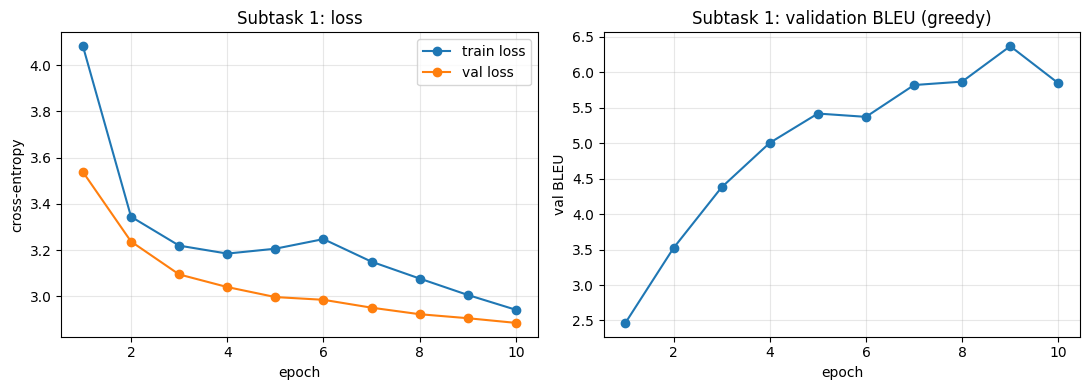

saved: ['s1_best.pt', 's1_curves.png', 's1_history.json', 's1_test_outputs.json']


In [16]:
import json
import matplotlib.pyplot as plt
g = np.random.default_rng(1)
pick = [int(i) for i in g.choice(len(ids), 4, replace=False)]
long_idx = [int(i) for i in np.argsort(-src_len)[:200] if 40 <= src_len[i] <= 80][:2]
for i in pick + long_idx:
    print("EN :", te.en[i][:170]); print("REF:", te.fr[i][:170]); print("HYP:", hyps[i][:170]); print()

h = np.array(history)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h[:, 0], h[:, 2], marker="o", label="train loss"); ax[0].plot(h[:, 0], h[:, 3], marker="o", label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("Subtask 1: loss")
ax[1].plot(h[:, 0], h[:, 4], marker="o"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val BLEU"); ax[1].grid(alpha=0.3); ax[1].set_title("Subtask 1: validation BLEU (greedy)")
plt.tight_layout(); plt.savefig("/kaggle/working/s1_curves.png", dpi=150, bbox_inches="tight"); plt.show()

json.dump({"test_hyp": hyps, "test_ref": refs, "test_bleu": te_bleu, "config": cfg, "best_val_bleu": float(best_bleu)}, open("/kaggle/working/s1_test_outputs.json", "w"))
print("saved:", sorted(f for f in os.listdir("/kaggle/working") if f.startswith("s1_")))

## Examples and failure modes

In the examples the first words are often right and quality then degrades: repeated function words
("et, et, et, et"), runs of commas, "ce que ce que", and `<unk>` for rare words. Long sentences
(over 40 tokens) degrade most. One output ("et c'est ce qu'ils ont fait" for "And they did.") is a
fluent paraphrase that differs from the reference ("Et elles se sont tues."), which BLEU penalises,
so BLEU understates quality for such cases. Failure modes: (1) the fixed-size context vector
(long sentences), (2) a word-level vocabulary (`<unk>`), (3) exposure bias and greedy decoding
(loops), (4) a short training budget and a noisy, partly misaligned corpus.

In [17]:
va = data["val"]
va_bleu, va_hyp = bleu_on(model, va, va_src)
vi = sorted(va_hyp); vh = [va_hyp[i] for i in vi]; vr = [va.fr[i] for i in vi]
v_len = np.array([len(tok_en(s)) for s in va.en])
vsub = lambda m: bl.corpus_score([h for h, k in zip(vh, m) if k], [[r for r, k in zip(vr, m) if k]]).score
rows = []
for lo, hi in [(1, 10), (11, 20), (21, 30), (31, 50), (51, 1000)]:
    mv = (v_len >= lo) & (v_len <= hi); mt = (src_len >= lo) & (src_len <= hi)
    rows.append(("%d-%d" % (lo, hi) if hi < 1000 else ">%d" % (lo - 1), int(mv.sum()), 100 * mv.mean(), vsub(mv) if mv.sum() > 20 else float("nan"), int(mt.sum()), 100 * mt.mean(), sub(mt)))
print("validation BLEU recomputed: %.2f (training log said 6.37) | sources with an <unk>: val %.1f%% vs test %.1f%%" % (va_bleu, 100 * np.mean([3 in s for s in va_src]), 100 * has_unk.mean()))
print(pd.DataFrame(rows, columns=["source length", "val sentences", "val share %", "val BLEU", "test sentences", "test share %", "test BLEU"]).round(2).to_string(index=False))
print("mean source length: val %.1f | test %.1f | median: val %d | test %d" % (v_len.mean(), src_len.mean(), np.median(v_len), np.median(src_len)))

validation BLEU recomputed: 6.37 (training log said 6.37) | sources with an <unk>: val 48.3% vs test 43.6%
source length  val sentences  val share %  val BLEU  test sentences  test share %  test BLEU
         1-10            184        20.67     14.46            2325         27.04      19.67
        11-20            324        36.40      8.52            3226         37.52      12.66
        21-30            193        21.69      7.59            1682         19.56       8.40
        31-50            139        15.62      4.36            1117         12.99       5.71
          >50             50         5.62      2.69             247          2.87       3.99
mean source length: val 22.2 | test 19.2 | median: val 18 | test 16
